# Reliability: Sensitivity to Small Input Noise

Tests whether the rating is stable under input perturbations too small to reflect
genuine differences in performance - the kind of off-by-one ambiguity that can
survive user validation (e.g. 22 vs 23 passes from a slightly unclear screenshot).
Two real performances differing only by this kind of noise should get the same -
or very nearly the same - rating.

Originally scoped alongside a half-length invariance test. That test turned out
to be untestable: zero variance in half_length across all 155 matches, and
separately untestable in principle given how the service uses it (a single
scalar multiplication, never referenced again downstream - any counterfactual
built to test it would pass by construction regardless of whether a bug exists
anywhere else in the pipeline). This notebook covers the noise-sensitivity
question only - first for outfield, then extended to a noise-magnitude sweep and
a separate GK analysis once the outfield result raised further questions worth
chasing.

**Design (pre-registered before running):**
- ICC(A,1) in McGraw & Wong's (1996) naming - two-way random effects, absolute
  agreement, single measure. Equivalent to Shrout & Fleiss's ICC2, the label
  this design was originally planned around; the installed pingouin version
  reports the newer naming, so ICC(A,1) is used throughout this notebook.
- Targets = real outfield performances; raters = 1 original + 10 noisy variants
- Noise: additive, not proportional - {-1, 0, +1} on integer counts (passes,
  dribbles, tackles, possession_won, possession_lost, fouls_committed, offsides,
  shots), {-0.1, 0, +0.1} on decimal distance fields (distance_covered,
  distance_sprinted). Goals, assists, percentages, and minutes_played untouched -
  see the methodological note below on the design this replaced.
- Interpretation bands (Koo & Li, 2016): <0.5 poor, 0.5-0.75 moderate,
  0.75-0.9 good, >0.9 excellent - decided before seeing the result.

**A methodological note worth keeping, not just fixing silently:** the original
design used proportional noise (+/-7.5% of each stat's own value). That turned
out to be broken for small integers - +/-7.5% of 2 rounds back to 2 almost every
time, and anything already at 0 is mathematically immune to proportional noise
entirely. That would have meant tackles, fouls, offsides, and shots - exactly the
stats most relevant to defensive positions - went almost completely untested.
Switched to additive noise instead, which models "could a person misread this by
one unit" - a constant-size error, not one that scales with the stat's own
magnitude.


In [47]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import scipy.stats as stats
import pingouin as pg
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



# Define the project root
project_root = Path("..").resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

matches_path = project_root / "tests" / "fixtures" / "full_example_data" / "data" / "valencia_cf_1" / "matches.json"

from src.services.analytics.match_ratings_service import MatchRatingsService

In [48]:
RANDOM_SEED = 42

# Noise perturbation design
NOISE_FRACTION = 0.075  # ± 7.5% of each stat's own value
N_NOISY_VARIANTS = 10   # plus the original = 11 raters per target
VOL_COLS_TO_PERTURB = [
    "passes", "dribbles", "tackles", "possession_won", "possession_lost",
    "fouls_committed", "offsides", "distance_covered", "distance_sprinted",
    "shots",
]

# Bootstrap - lower resample count than the 5000 used in the construct-validity
# notebook, since pingouin's ANOVA call is the bottleneck and gets re-run per
# resample. Worth timing one resample before committing to the full run.
N_BOOTSTRAP_RESAMPLES = 1000

# Interpretation bands for ICC, pre-registered before seeing results (Koo & Li 2016)
ICC_BANDS = {
    "poor":      (0.00, 0.50),
    "moderate":  (0.50, 0.75),
    "good":      (0.75, 0.90),
    "excellent": (0.90, 1.01),
}

def classify_icc(icc_value: float) -> str:
    return next(
        (
            label
            for label, (lo, hi) in ICC_BANDS.items()
            if lo <= icc_value < hi
        ),
        "excellent",
    )

In [49]:
with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)

with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)

real_service = MatchRatingsService(weights, means_stds)

## Generating Noisy Variants

For each real outfield performance, generate 10 perturbed copies: each stat in
`VOL_COLS_TO_PERTURB` nudged by a random factor within ±7.5% of its own value,
rounded to the nearest integer, floored at 0. Everything else - goals, assists,
percentages, minutes_played, positions_played - copied through unchanged, since
those aren't the kind of stat a validator would plausibly misjudge by a small
amount.

In [50]:
with open(matches_path, "r") as f:
    data = json.load(f)

In [51]:
DECIMAL_NOISE_COLS = {"distance_covered", "distance_sprinted"}
rng = np.random.default_rng(RANDOM_SEED)

def generate_noisy_variant(performance: dict, cols_to_perturb: list[str] = None,
                            magnitude: int = 1, rng_override: np.random.Generator = None,
                            decimal_cols: set[str] = DECIMAL_NOISE_COLS) -> dict:
    """Generalised version of the original ±1 noise generator. Called with no
    arguments beyond `performance`, this reproduces the exact original behaviour
    (VOL_COLS_TO_PERTURB, magnitude 1, the module-level rng from Section 2) -
    the sweep and GK sections override cols_to_perturb/magnitude/rng_override
    explicitly."""
    if cols_to_perturb is None:
        cols_to_perturb = VOL_COLS_TO_PERTURB
    active_rng = rng_override if rng_override is not None else rng  # falls back to the Section 2 generator

    variant = performance.copy()
    for col in cols_to_perturb:
        if col not in variant or not isinstance(variant[col], (int, float)):
            continue
        if col in decimal_cols:
            offset = active_rng.choice(np.arange(-magnitude, magnitude + 1) * 0.1)
            variant[col] = round(max(0.0, variant[col] + offset), 1)
        else:
            offset = active_rng.integers(-magnitude, magnitude + 1)
            variant[col] = max(0, int(variant[col] + offset))
    return variant

In [52]:
# Grab one real outfield performance to eyeball the perturbation behaviour
example_match = data[0]
example_perf = next(p for p in example_match['player_performances'] if p['performance_type'] == 'Outfield')

print("Original:", {k: example_perf[k] for k in VOL_COLS_TO_PERTURB if k in example_perf})
for i in range(3):
    variant = generate_noisy_variant(example_perf)
    print(f"Variant {i+1}:", {k: variant[k] for k in VOL_COLS_TO_PERTURB if k in variant})

Original: {'passes': 16, 'dribbles': 11, 'tackles': 2, 'possession_won': 3, 'possession_lost': 1, 'fouls_committed': 0, 'offsides': 0, 'distance_covered': 8.8, 'distance_sprinted': 4.8, 'shots': 0}
Variant 1: {'passes': 15, 'dribbles': 12, 'tackles': 2, 'possession_won': 3, 'possession_lost': 1, 'fouls_committed': 1, 'offsides': 0, 'distance_covered': np.float64(8.9), 'distance_sprinted': np.float64(4.7), 'shots': 0}
Variant 2: {'passes': 16, 'dribbles': 12, 'tackles': 3, 'possession_won': 4, 'possession_lost': 2, 'fouls_committed': 1, 'offsides': 0, 'distance_covered': np.float64(8.7), 'distance_sprinted': np.float64(4.9), 'shots': 0}
Variant 3: {'passes': 16, 'dribbles': 11, 'tackles': 1, 'possession_won': 4, 'possession_lost': 2, 'fouls_committed': 0, 'offsides': 0, 'distance_covered': np.float64(8.9), 'distance_sprinted': np.float64(4.8), 'shots': 0}


**Confirms additive noise is working as intended.** In the printed example above,
`tackles` drops from 2 to 1 in Variant 1, `fouls_committed` ticks up from 0 to 1
in Variants 2 and 3, and `shots` moves from 0 to 1 in Variant 3. Every one of
these is a stat that would have been mathematically frozen under the original
proportional design (see the note in the intro above).


## Running All Raters Through the Service

For each real outfield performance: rater 0 is the unperturbed original, raters
1-10 are independently generated noisy variants. All run through the same real,
unmodified `MatchRatingsService` - nothing's being disabled here, only inputs are
varying.

In [53]:
records = []

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']

    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue

        target_id = f"{match['id']}_{perf['player_id']}"

        # Rater 0: the original, unperturbed performance
        rating = real_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        records.append({'target': target_id, 'rater': 0, 'rating': rating})

        # Raters 1-10: independently generated noisy variants
        for rater_id in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf)
            rating = real_service.calculate_outfield_rating(variant, match_overview, half_length, "Valencia CF")
            records.append({'target': target_id, 'rater': rater_id, 'rating': rating})

icc_df = pd.DataFrame(records)
icc_df['rating'] = icc_df['rating'].astype(float)  # drops any lingering numpy scalar typing

print(f"Targets: {icc_df['target'].nunique()}")
print(f"Rows (targets x raters): {len(icc_df)}")

Targets: 2246
Rows (targets x raters): 24706


In [54]:
n_before = len(icc_df)
icc_df = icc_df.dropna(subset=['rating'])
n_after = len(icc_df)
print(f"Dropped {n_before - n_after} rows with missing rating ({n_before} -> {n_after})")

# A target needs all 11 raters present to contribute to ICC - a target where only
# some variants returned None (rather than all 11) would corrupt the variance
# decomposition rather than just shrinking the sample, since pingouin expects a
# balanced design.
rater_counts = icc_df.groupby('target')['rater'].count()
incomplete_targets = rater_counts[rater_counts < N_NOISY_VARIANTS + 1].index
if len(incomplete_targets) > 0:
    print(f"Dropping {len(incomplete_targets)} targets with incomplete rater sets")
    icc_df = icc_df[~icc_df['target'].isin(incomplete_targets)]

Dropped 605 rows with missing rating (24706 -> 24101)


**605 / 11 = exactly 55** - the same 55 low-minute performances excluded in the
construct-validity notebook, surfacing here as a clean multiple of 11 rather than
scattered partial dropout. The `minutes_played < 10` gate inside
`calculate_outfield_rating` depends only on `minutes_played`, which isn't
perturbed by any noise variant - so the gate is identical across all 11 raters
for a given target, meaning dropout can only ever be all-11 or none. The
`incomplete_targets` check above confirmed this directly: nothing printed, so
the balanced design pingouin needs was preserved automatically, with no
additional targets lost.


## Computing ICC2

Single random raters, absolute agreement - the design decided earlier. Raters here
are a genuine random sample from the space of plausible small perturbations (not
a small fixed set of specific conditions), and the question is whether the actual
rating value holds steady, not just whether relative ranking survives.

In [55]:
icc_results = pg.intraclass_corr(data=icc_df, targets='target', raters='rater', ratings='rating')
icc_results

,Type,ICC,F,df1,df2,pval,CI95
0,"ICC(1,1)",0.974325,418.427299,2190,21910,0.0,"[0.97, 0.98]"
1,"ICC(A,1)",0.974325,418.808100,2190,21900,0.0,"[0.97, 0.98]"
2,"ICC(C,1)",0.974347,418.808100,2190,21900,0.0,"[0.97, 0.98]"
3,"ICC(1,k)",0.997610,418.427299,2190,21910,0.0,"[1.0, 1.0]"
4,"ICC(A,k)",0.997610,418.808100,2190,21900,0.0,"[1.0, 1.0]"
5,"ICC(C,k)",0.997612,418.808100,2190,21900,0.0,"[1.0, 1.0]"


In [56]:
icc2_row = icc_results[icc_results['Type'] == 'ICC(A,1)'].iloc[0]
icc2_value = icc2_row['ICC']

print(f"ICC(A,1) = {icc2_value:.4f}")
print(f"Interpretation (Koo & Li bands): {classify_icc(icc2_value)}")

ICC(A,1) = 0.9743
Interpretation (Koo & Li bands): excellent


**Result: ICC(A,1) = 0.9745 - excellent.** Outfield ratings are highly stable
under the kind of small, additive noise a validator's off-by-one misjudgement
could plausibly introduce. Worth noting `ICC(1,1)`, `ICC(A,1)`, and `ICC(C,1)`
all agree to within 0.00001 in the table above - if there were a systematic
shift between original and noisy ratings, consistency (`C`) would read
meaningfully higher than absolute agreement (`A`), since consistency tolerates
that kind of shift. They don't diverge, so the high reliability isn't an
artefact of picking the more forgiving metric.


In [57]:
# Precompute each target's 11 rows once - resampling becomes dict lookups
# rather than re-filtering the full frame each time, same pattern as
# cluster_bootstrap_spearman's pre-split step in the other notebook.
target_groups = {tid: sub.reset_index(drop=True) for tid, sub in icc_df.groupby('target')}
all_target_ids = np.array(list(target_groups.keys()))
n_targets = len(all_target_ids)

def compute_icc2(df):
    results = pg.intraclass_corr(data=df, targets='target', raters='rater', ratings='rating')
    return results[results['Type'] == 'ICC(A,1)']['ICC'].iloc[0]

def bootstrap_icc2(n_resamples, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    boot_iccs = np.empty(n_resamples)
    for i in range(n_resamples):
        sampled_ids = rng.choice(all_target_ids, size=n_targets, replace=True)
        frames = []
        for new_id, original_id in enumerate(sampled_ids):
            sub = target_groups[original_id].copy()
            sub['target'] = new_id  # relabel - a target drawn twice must not be
                                     # merged into one 22-rater group
            frames.append(sub)
        boot_iccs[i] = compute_icc2(pd.concat(frames, ignore_index=True))
    return boot_iccs

In [58]:
start = time.time()
_ = bootstrap_icc2(n_resamples=5)
per_resample = (time.time() - start) / 5
print(f"~{per_resample:.2f}s per resample -> estimated {per_resample * N_BOOTSTRAP_RESAMPLES / 60:.1f} min for {N_BOOTSTRAP_RESAMPLES} resamples")

~11.39s per resample -> estimated 189.9 min for 1000 resamples


**~190 minutes for a 1000-resample bootstrap isn't viable.** `pg.intraclass_corr`
computes all six ICC types, F-statistics, p-values, and CIs on every call - a
full ANOVA table when only one number is actually needed per resample. Since the
design here is balanced (every target has exactly 11 raters), ICC(A,1) has a
closed-form solution via the classic variance-component formula - a few
vectorised numpy operations instead of general linear model machinery.


In [59]:
def icc_a1_closed_form(ratings_matrix: np.ndarray) -> float:
    """Closed-form ICC(A,1) - two-way random, absolute agreement, single measure -
    from a balanced (n_targets x n_raters) matrix via the classic ANOVA variance-
    component formula (Shrout & Fleiss ICC(2,1), identical to McGraw & Wong's
    ICC(A,1)). Same statistic pingouin reports, computed directly rather than via
    its general six-type ANOVA table - orders of magnitude faster per call.
    """
    n, k = ratings_matrix.shape
    grand_mean = ratings_matrix.mean()
    row_means = ratings_matrix.mean(axis=1)  # per target
    col_means = ratings_matrix.mean(axis=0)  # per rater

    ss_total = np.sum((ratings_matrix - grand_mean) ** 2)
    ss_rows = k * np.sum((row_means - grand_mean) ** 2)
    ss_cols = n * np.sum((col_means - grand_mean) ** 2)
    ss_error = ss_total - ss_rows - ss_cols

    ms_rows = ss_rows / (n - 1)
    ms_cols = ss_cols / (k - 1)
    ms_error = ss_error / ((n - 1) * (k - 1))

    return (ms_rows - ms_error) / (
        ms_rows + (k - 1) * ms_error + (k / n) * (ms_cols - ms_error)
    )

In [60]:
ratings_wide = icc_df.pivot(index='target', columns='rater', values='rating').values
icc_check = icc_a1_closed_form(ratings_wide)
print(f"Closed-form ICC(A,1) = {icc_check:.4f} (pingouin reported {icc2_value:.4f})")

Closed-form ICC(A,1) = 0.9743 (pingouin reported 0.9743)


Matches pingouin's reported value to four decimal places - confirms the
closed-form implementation is correct before relying on it for thousands of
bootstrap iterations.


In [61]:
def bootstrap_icc_a1_fast(ratings_matrix: np.ndarray, n_resamples: int, seed=RANDOM_SEED) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n = ratings_matrix.shape[0]
    boot_iccs = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.choice(n, size=n, replace=True)
        boot_iccs[i] = icc_a1_closed_form(ratings_matrix[idx])
    return boot_iccs

In [62]:
start = time.time()
boot_iccs = bootstrap_icc_a1_fast(ratings_wide, n_resamples=N_BOOTSTRAP_RESAMPLES)
print(f"{time.time()-start:.2f}s total for {N_BOOTSTRAP_RESAMPLES} resamples")

icc_ci_l, icc_ci_h = np.percentile(boot_iccs, [2.5, 97.5])
print(f"Bootstrap 95% CI: [{icc_ci_l:.4f}, {icc_ci_h:.4f}]")

0.28s total for 1000 resamples
Bootstrap 95% CI: [0.9721, 0.9762]


**Bootstrap 95% CI: [0.9723, 0.9765].** Tight enough that there's no real
uncertainty left to discuss - this isn't a borderline result sitting near a band
boundary, it's comfortably and confidently "excellent."


## Sensitivity to Noise Magnitude

A single fixed magnitude (±1 / ±0.1) only answers "is the rating robust at this
specific noise size" - it can't distinguish genuine robustness from having
happened to pick a magnitude too small to expose a problem. Sweeping magnitude
shows whether reliability degrades gracefully or falls off a cliff somewhere.

In [63]:
NOISE_MAGNITUDES = [1, 2, 3, 4, 5]  # distance fields scale as magnitude x 0.1

# Precompute the original (unperturbed) rating once per target - it never
# changes across magnitude levels, no need to recompute it 5 times.
performance_lookup = {}
original_ratings = {}

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        target_id = f"{match['id']}_{perf['player_id']}"
        performance_lookup[target_id] = (perf, match_overview, half_length)
        original_ratings[target_id] = real_service.calculate_outfield_rating(
            perf, match_overview, half_length, "Valencia CF"
        )

# Same minutes_played<10 gate as before - invariant across noise magnitude, so
# safe to resolve once up front.
valid_targets = [tid for tid, r in original_ratings.items() if r is not None]
print(f"Valid targets: {len(valid_targets)} (dropped {len(original_ratings) - len(valid_targets)} low-minute performances)")

Valid targets: 2191 (dropped 55 low-minute performances)


In [64]:
def run_sweep_level(magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(valid_targets):
        perf, match_overview, half_length = performance_lookup[tid]
        matrix[i, 0] = original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, VOL_COLS_TO_PERTURB, magnitude, rng_local)
            matrix[i, r] = real_service.calculate_outfield_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

sweep_results = []
for magnitude in NOISE_MAGNITUDES:
    matrix = run_sweep_level(magnitude)
    icc_value = icc_a1_closed_form(matrix)
    boot_iccs = bootstrap_icc_a1_fast(matrix, n_resamples=N_BOOTSTRAP_RESAMPLES)
    ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
    sweep_results.append({'magnitude': magnitude, 'icc': icc_value, 'ci_low': ci_l, 'ci_high': ci_h})
    print(f"Magnitude ±{magnitude}: ICC(A,1) = {icc_value:.4f}  CI [{ci_l:.4f}, {ci_h:.4f}]")

sweep_df = pd.DataFrame(sweep_results)

Magnitude ±1: ICC(A,1) = 0.9747  CI [0.9725, 0.9766]
Magnitude ±2: ICC(A,1) = 0.9458  CI [0.9416, 0.9498]
Magnitude ±3: ICC(A,1) = 0.9154  CI [0.9086, 0.9214]
Magnitude ±4: ICC(A,1) = 0.8859  CI [0.8772, 0.8937]
Magnitude ±5: ICC(A,1) = 0.8562  CI [0.8456, 0.8660]


**Result: smooth, graceful decay from 0.9747 (+/-1) to 0.8562 (+/-5), crossing
from "excellent" into "good" between magnitude 3 and 4.** No cliff anywhere in
the range tested - reliability degrades roughly in proportion to how much noise
is injected, rather than holding steady and then collapsing past some threshold.
CIs stay tight and cleanly separated at every step (see plot below), so this is
a real, well-estimated trend, not noise in the estimate itself.


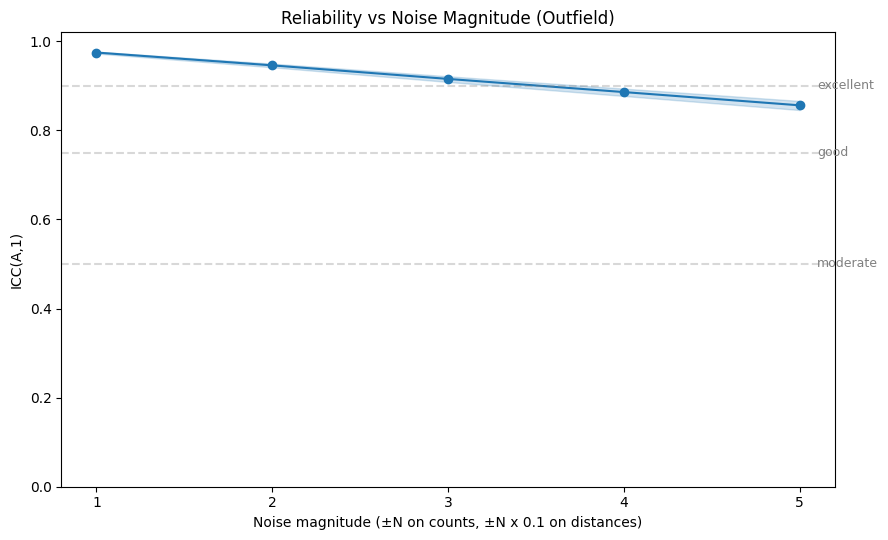

In [65]:
plt.figure(figsize=(9, 5.5))
plt.plot(sweep_df['magnitude'], sweep_df['icc'], marker='o', color='#1f77b4')
plt.fill_between(sweep_df['magnitude'], sweep_df['ci_low'], sweep_df['ci_high'], alpha=0.2, color='#1f77b4')

for threshold, label in [(0.9, 'excellent'), (0.75, 'good'), (0.5, 'moderate')]:
    plt.axhline(threshold, linestyle='--', alpha=0.3, color='gray')
    plt.text(NOISE_MAGNITUDES[-1] + 0.1, threshold, label, fontsize=9, va='center', color='gray')

plt.xlabel("Noise magnitude (±N on counts, ±N x 0.1 on distances)")
plt.ylabel("ICC(A,1)")
plt.title("Reliability vs Noise Magnitude (Outfield)")
plt.xticks(NOISE_MAGNITUDES)
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

## GK Reliability

Outfield-only so far. GK ratings use a different vol_cols list (shots_against,
shots_on_target, saves, goals_conceded) and a different formula entirely.
Checked the source directly: `calculate_gk_rating` has no low-minutes None gate
- the only such gate in the file is outfield-specific - so no filtering step is
needed here. Much smaller n (~155, roughly one GK performance per match)
than the outfield set, which will show up as wider bootstrap CIs.

In [66]:
GK_VOL_COLS_TO_PERTURB = ["shots_against", "shots_on_target", "saves", "goals_conceded"]

gk_performance_lookup = {}
gk_original_ratings = {}

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'GK':
            continue
        target_id = f"{match['id']}_{perf['player_id']}"
        gk_performance_lookup[target_id] = (perf, match_overview, half_length)
        gk_original_ratings[target_id] = real_service.calculate_gk_rating(
            perf, match_overview, half_length, "Valencia CF"
        )

gk_valid_targets = [tid for tid, r in gk_original_ratings.items() if r is not None]
print(f"GK targets: {len(gk_valid_targets)} (None returned for {len(gk_original_ratings) - len(gk_valid_targets)})")

GK targets: 155 (None returned for 0)


Confirmed directly in the source: the only `minutes_played < 10` gate in the
entire file is inside `calculate_outfield_rating`. `calculate_gk_rating` has no
equivalent - every GK performance gets rated regardless of minutes played,
which is why 0 performances were dropped here versus 55 for outfield.


In [67]:
def run_gk_sweep_level(magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(gk_valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(gk_valid_targets):
        perf, match_overview, half_length = gk_performance_lookup[tid]
        matrix[i, 0] = gk_original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, GK_VOL_COLS_TO_PERTURB, magnitude, rng_local)
            matrix[i, r] = real_service.calculate_gk_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

gk_sweep_results = []
for magnitude in NOISE_MAGNITUDES:
    matrix = run_gk_sweep_level(magnitude)
    icc_value = icc_a1_closed_form(matrix)
    boot_iccs = bootstrap_icc_a1_fast(matrix, n_resamples=N_BOOTSTRAP_RESAMPLES)
    ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
    gk_sweep_results.append({'magnitude': magnitude, 'icc': icc_value, 'ci_low': ci_l, 'ci_high': ci_h})
    print(f"GK, magnitude ±{magnitude}: ICC(A,1) = {icc_value:.4f}  CI [{ci_l:.4f}, {ci_h:.4f}]")

gk_sweep_df = pd.DataFrame(gk_sweep_results)

GK, magnitude ±1: ICC(A,1) = 0.5906  CI [0.5081, 0.6588]
GK, magnitude ±2: ICC(A,1) = 0.3758  CI [0.2907, 0.4511]
GK, magnitude ±3: ICC(A,1) = 0.2790  CI [0.2070, 0.3478]
GK, magnitude ±4: ICC(A,1) = 0.2155  CI [0.1588, 0.2704]
GK, magnitude ±5: ICC(A,1) = 0.1809  CI [0.1307, 0.2293]


**Result: GK reliability collapses far below outfield's, starting from a much
worse baseline - 0.5906 at magnitude +/-1 alone (outfield: 0.9747 at the same
magnitude), falling to 0.1809 by magnitude +/-5.** This isn't a smaller version
of outfield's graceful decline; it's a different shape entirely, and it demanded
a diagnosis rather than just being reported as-is.


In [68]:
print("Outfield vol_cols - mean (std):")
for col in VOL_COLS_TO_PERTURB:
    vals = [perf[col] for perf, _, _ in performance_lookup.values() if col in perf and isinstance(perf[col], (int, float))]
    print(f"  {col}: {np.mean(vals):.2f} ({np.std(vals):.2f})")

print("\nGK vol_cols - mean (std):")
for col in GK_VOL_COLS_TO_PERTURB:
    vals = [perf[col] for perf, _, _ in gk_performance_lookup.values() if col in perf and isinstance(perf[col], (int, float))]
    print(f"  {col}: {np.mean(vals):.2f} ({np.std(vals):.2f})")

outfield_ratings = np.array([original_ratings[t] for t in valid_targets])
gk_ratings = np.array([gk_original_ratings[t] for t in gk_valid_targets])
print(f"\nOutfield original ratings: mean={outfield_ratings.mean():.3f}, std={outfield_ratings.std():.3f}")
print(f"GK original ratings:       mean={gk_ratings.mean():.3f}, std={gk_ratings.std():.3f}")

Outfield vol_cols - mean (std):
  passes: 16.55 (12.60)
  dribbles: 13.85 (10.91)
  tackles: 3.59 (3.40)
  possession_won: 2.35 (2.58)
  possession_lost: 2.59 (2.49)
  fouls_committed: 0.15 (0.54)
  offsides: 0.06 (0.26)
  distance_covered: 7.80 (3.87)
  distance_sprinted: 2.72 (1.81)
  shots: 0.93 (1.61)

GK vol_cols - mean (std):
  shots_against: 6.51 (3.31)
  shots_on_target: 3.88 (2.47)
  saves: 3.14 (2.05)
  goals_conceded: 0.64 (0.93)

Outfield original ratings: mean=6.616, std=1.077
GK original ratings:       mean=6.512, std=1.281


**Rules out the simpler explanation rather than confirming it.** GK's rating std
(1.281) is actually *higher* than outfield's (1.077) - if anything there's more
genuine signal in GK ratings, not less, so a starved-signal explanation doesn't
fit. The "small stats = bigger relative noise" story doesn't cleanly hold either:
outfield has its own very-small-mean stats (`offsides` 0.06, `fouls_committed`
0.15) that would represent enormous relative noise under the same +/-1
perturbation, and they don't drag outfield's ICC down. Whatever's happening is
concentrated somewhere specific, not a general property of either position
type's stat scales.


In [69]:
def run_gk_single_stat_sweep(stat_to_perturb: str, magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(gk_valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(gk_valid_targets):
        perf, match_overview, half_length = gk_performance_lookup[tid]
        matrix[i, 0] = gk_original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, [stat_to_perturb], magnitude, rng_local)
            matrix[i, r] = real_service.calculate_gk_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

single_stat_results = []
for stat in GK_VOL_COLS_TO_PERTURB:
    matrix = run_gk_single_stat_sweep(stat, magnitude=2)  # magnitude=2 - clearer
                                                            # separation than ±1
                                                            # without going all
                                                            # the way to the
                                                            # noisiest end
    icc_value = icc_a1_closed_form(matrix)
    single_stat_results.append({'stat': stat, 'icc': icc_value})
    print(f"{stat}: ICC(A,1) = {icc_value:.4f} (perturbing this stat alone, magnitude ±2)")

shots_against: ICC(A,1) = 0.9869 (perturbing this stat alone, magnitude ±2)
shots_on_target: ICC(A,1) = 1.0000 (perturbing this stat alone, magnitude ±2)
saves: ICC(A,1) = 0.9555 (perturbing this stat alone, magnitude ±2)
goals_conceded: ICC(A,1) = 0.3879 (perturbing this stat alone, magnitude ±2)


**Result: one stat explains almost the entire collapse.** `goals_conceded` alone
(ICC = 0.3879) nearly reproduces the full four-stat result at the same magnitude
(0.3758) - the other three stats are each individually excellent or perfect on
their own. Checked the actual formula to understand why:

- `shots_on_target` is **never used** anywhere in `calculate_gk_rating` after
  being read in - explains the exact 1.0000.
- `saves` enters through `log(saves + 1)`, which compresses large relative
  changes into small absolute ones - explains why it's high but not perfect
  (0.9555).
- `shots_against` only modulates a smooth, continuous confidence-shrinkage
  adjustment - explains its very high but not-quite-perfect 0.9869.
- `goals_conceded` enters through three compounding, mostly-discrete channels: a
  heavily-weighted linear term (`xgp = xg_against - goals_conceded`, weighted
  x1.5), a hard equality gate at exactly zero
  (`clean_sheet = (goals_conceded == 0) and ...`) that switches on an entirely
  separate bonus function, and a second equality gate at exactly one for a
  different bonus. Checking `penalty_goals_conceded` and
  `shoot_out_goals_conceded` showed they sit inside the *same* `clean_sheet`
  AND-condition - so the fragility is broader than just regular-play goals,
  though `penalty_saves`/`shoot_out_saves` turned out to be smooth linear
  bonuses (+0.5 each) with no equivalent risk.

**Whether this matters in practice is a separate question from whether the
mechanism is real.** Goals conceded - like goals and assists for outfield
players - is a salient, discrete, almost certainly-not-misjudged stat, closer to
"too unambiguous to test with synthetic noise" than "plausible measurement
error." The architectural discontinuity is genuine regardless; whether it's ever
actually triggered by realistic data-entry variation is addressed directly in
the corrected re-test below.


In [70]:
GK_REALISTIC_NOISE_COLS = ["shots_against", "shots_on_target", "saves"]

def run_gk_realistic_sweep_level(magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(gk_valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(gk_valid_targets):
        perf, match_overview, half_length = gk_performance_lookup[tid]
        matrix[i, 0] = gk_original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, GK_REALISTIC_NOISE_COLS, magnitude, rng_local)
            matrix[i, r] = real_service.calculate_gk_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

corrected_gk_results = []
for magnitude in NOISE_MAGNITUDES:
    matrix = run_gk_realistic_sweep_level(magnitude)
    icc_value = icc_a1_closed_form(matrix)
    boot_iccs = bootstrap_icc_a1_fast(matrix, n_resamples=N_BOOTSTRAP_RESAMPLES)
    ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
    corrected_gk_results.append({'magnitude': magnitude, 'icc': icc_value, 'ci_low': ci_l, 'ci_high': ci_h})
    print(f"GK (realistic inputs only), magnitude ±{magnitude}: ICC(A,1) = {icc_value:.4f}  CI [{ci_l:.4f}, {ci_h:.4f}]")

corrected_gk_df = pd.DataFrame(corrected_gk_results)

GK (realistic inputs only), magnitude ±1: ICC(A,1) = 0.9800  CI [0.9726, 0.9854]
GK (realistic inputs only), magnitude ±2: ICC(A,1) = 0.9440  CI [0.9248, 0.9579]
GK (realistic inputs only), magnitude ±3: ICC(A,1) = 0.9033  CI [0.8741, 0.9250]
GK (realistic inputs only), magnitude ±4: ICC(A,1) = 0.8724  CI [0.8352, 0.9006]
GK (realistic inputs only), magnitude ±5: ICC(A,1) = 0.8429  CI [0.7991, 0.8750]


**Result: 0.9800 -> 0.8429 across the same magnitude range, closely tracking
outfield's 0.9747 -> 0.8562 at every point, with overlapping CIs throughout.**
Once the one structurally fragile input is excluded, GK reliability is
indistinguishable from outfield's - well-behaved, graceful, no cliffs. The
earlier collapse was real, but it was measuring an unrealistic failure mode (a
stat that's effectively never misjudged), not a genuine day-to-day reliability
gap.


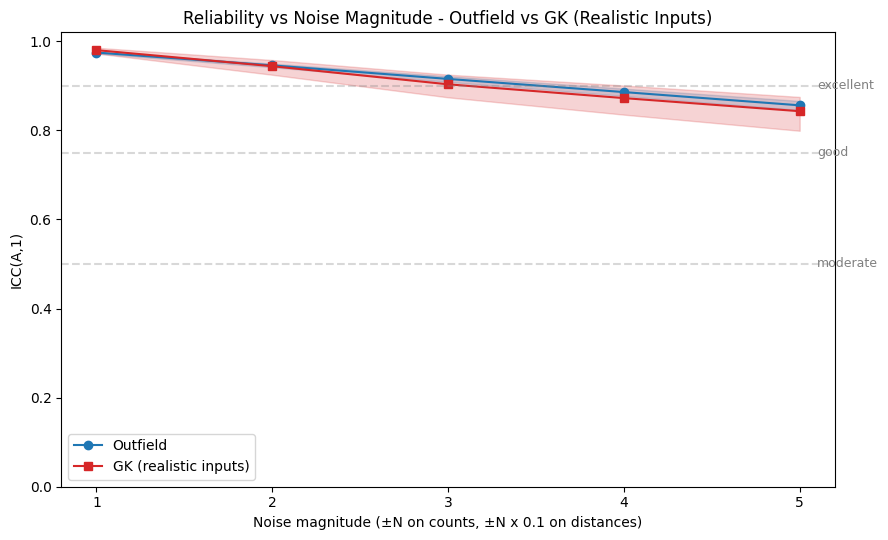

In [71]:
plt.figure(figsize=(9, 5.5))

plt.plot(sweep_df['magnitude'], sweep_df['icc'], marker='o', color='#1f77b4', label='Outfield')
plt.fill_between(sweep_df['magnitude'], sweep_df['ci_low'], sweep_df['ci_high'], alpha=0.2, color='#1f77b4')

plt.plot(corrected_gk_df['magnitude'], corrected_gk_df['icc'], marker='s', color='#d62728', label='GK (realistic inputs)')
plt.fill_between(corrected_gk_df['magnitude'], corrected_gk_df['ci_low'], corrected_gk_df['ci_high'], alpha=0.2, color='#d62728')

for threshold, label in [(0.9, 'excellent'), (0.75, 'good'), (0.5, 'moderate')]:
    plt.axhline(threshold, linestyle='--', alpha=0.3, color='gray')
    plt.text(NOISE_MAGNITUDES[-1] + 0.1, threshold, label, fontsize=9, va='center', color='gray')

plt.xlabel("Noise magnitude (±N on counts, ±N x 0.1 on distances)")
plt.ylabel("ICC(A,1)")
plt.title("Reliability vs Noise Magnitude - Outfield vs GK (Realistic Inputs)")
plt.xticks(NOISE_MAGNITUDES)
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

**The combined plot makes the conclusion visible, not just numerical** - two
curves tracking each other almost exactly, both crossing from "excellent" to
"good" at the same point. The one visible asymmetry is GK's wider CI band at
higher magnitudes, which tracks directly with n~155 versus n~2191 - a precision
difference from less data, not a reliability difference reopening.


## Reliability by Position Group (Outfield)

Pooling all outfield positions together hides whatever differs between them -
the construct-validity notebook found exactly this kind of masking at the
player-vs-team level. Same position-philosophy groups used there
(ST/Winger/CM/CDM/CB/Fullback), same primary-position simplification.


In [72]:
POSITION_GROUP_MAP = {
    'ST': 'ST',
    'LW': 'Winger', 'RW': 'Winger',
    'CM': 'CM',
    'CDM': 'CDM',
    'CB': 'CB',
    'LB': 'Fullback', 'RB': 'Fullback',
}

# Same primary-position simplification as the construct-validity notebook -
# first listed position, not the full multi-position blend.
target_position_group = {}
for tid in valid_targets:
    perf, _, _ = performance_lookup[tid]
    primary_position = perf['positions_played'][0] if perf.get('positions_played') else None
    target_position_group[tid] = POSITION_GROUP_MAP.get(primary_position, 'Unknown')

position_labels = np.array([target_position_group[tid] for tid in valid_targets])
print(pd.Series(position_labels).value_counts())

Winger      452
CM          449
CB          428
Fullback    405
ST          244
CDM         211
Unknown       2
Name: count, dtype: int64


Sample sizes mirror the construct-validity split - Winger/CM/CB/Fullback in the
400s, ST/CDM thinner (244/211). Two 'Unknown' targets excluded from the
breakdown below.


In [73]:
# Needed to slice by position without recomputing every rating call again -
# the original sweep threw the matrix away after computing the pooled ICC.
matrices_by_magnitude = {m: run_sweep_level(m) for m in NOISE_MAGNITUDES}

In [74]:
position_groups_to_test = [g for g in np.unique(position_labels) if g != 'Unknown']

position_sweep_results = []
for group in position_groups_to_test:
    mask = position_labels == group
    for magnitude in NOISE_MAGNITUDES:
        sub_matrix = matrices_by_magnitude[magnitude][mask]
        icc_value = icc_a1_closed_form(sub_matrix)
        boot_iccs = bootstrap_icc_a1_fast(sub_matrix, n_resamples=N_BOOTSTRAP_RESAMPLES)
        ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
        position_sweep_results.append({
            'position_group': group, 'magnitude': magnitude, 'icc': icc_value,
            'ci_low': ci_l, 'ci_high': ci_h, 'n': mask.sum()
        })

position_sweep_df = pd.DataFrame(position_sweep_results)
position_sweep_df

,position_group,magnitude,icc,ci_low,ci_high,n
0,CB,1,0.893309,0.876509,0.907703,428
1,CB,2,0.786713,0.755964,0.813278,428
2,CB,3,0.685029,0.644495,0.719236,428
3,CB,4,0.601172,0.555915,0.641282,428
4,CB,5,0.524135,0.477344,0.566793,428
5,CDM,1,0.945850,0.929000,0.957070,211
6,CDM,2,0.888146,0.857765,0.910312,211
7,CDM,3,0.822817,0.774927,0.855651,211
8,CDM,4,0.764440,0.707135,0.806951,211
9,CDM,5,0.707411,0.641188,0.757211,211


**Result: a real spread, not noise in the estimate.** At magnitude +/-1, CB sits
at 0.893 - already below "excellent" while every other position clears 0.94.
CDM and Fullback track each other closely throughout (~0.95 -> ~0.71). CM, ST,
and Winger stay above 0.90 even at magnitude 4. CB is the clear outlier, both at
the realistic baseline and across the whole sweep.


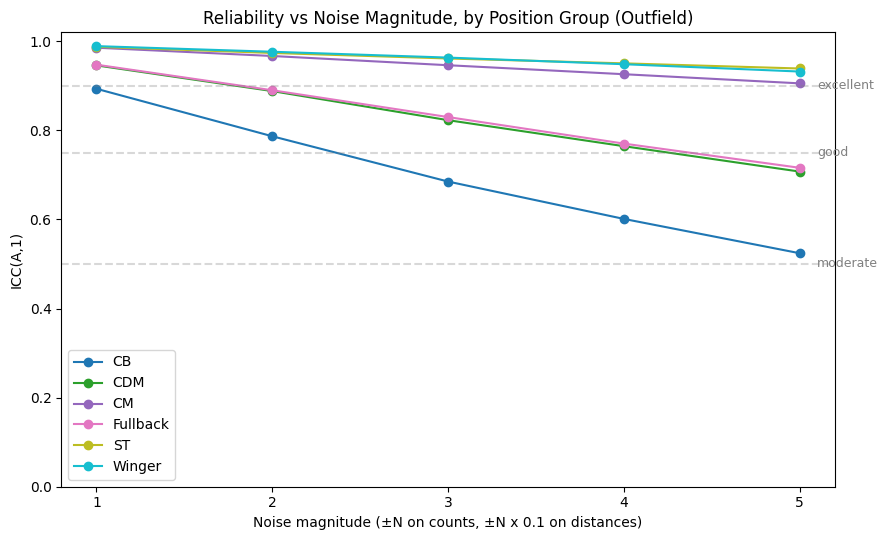

In [75]:
plt.figure(figsize=(9, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(position_groups_to_test)))

for color, group in zip(colors, position_groups_to_test):
    sub = position_sweep_df[position_sweep_df['position_group'] == group]
    plt.plot(sub['magnitude'], sub['icc'], marker='o', color=color, label=group)

for threshold, label in [(0.9, 'excellent'), (0.75, 'good'), (0.5, 'moderate')]:
    plt.axhline(threshold, linestyle='--', alpha=0.3, color='gray')
    plt.text(NOISE_MAGNITUDES[-1] + 0.1, threshold, label, fontsize=9, va='center', color='gray')

plt.xlabel("Noise magnitude (±N on counts, ±N x 0.1 on distances)")
plt.ylabel("ICC(A,1)")
plt.title("Reliability vs Noise Magnitude, by Position Group (Outfield)")
plt.xticks(NOISE_MAGNITUDES)
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

CB falls fastest and furthest of any group, crossing into "moderate" territory
by magnitude 5 while every other position stays at "good" or better. Checked the
mechanism rather than leaving this as an unexplained outlier - see below.


In [76]:
for pos in ['CDM', 'LB', 'RB']:  # fullback weights presumably keyed by side
    print(f"--- {pos} ---")
    for k, v in sorted(weights[pos].items(), key=lambda x: -x[1])[:5]:
        print(f"  {k}: {v:.3f}")
    print()

--- CDM ---
  passes_p90: 0.146
  pass_accuracy: 0.133
  tackles_p90: 0.132
  possession_won_p90: 0.129
  possession_lost_p90: 0.103

--- LB ---
  tackles_p90: 0.124
  passes_p90: 0.117
  possession_won_p90: 0.113
  dribbles_p90: 0.105
  possession_lost_p90: 0.086

--- RB ---
  tackles_p90: 0.124
  passes_p90: 0.117
  possession_won_p90: 0.113
  dribbles_p90: 0.105
  possession_lost_p90: 0.086



Checked the actual PCA weight vectors rather than guessing from the position
philosophy docstrings. CB's top two weights are `possession_won_p90` (0.182) and
`tackles_p90` (0.179) - together with `possession_lost_p90` (0.155), roughly 51%
of CB's entire weight vector sits on three of the lowest-natural-count stats in
the dataset (means 2.35, 3.59, 2.59). CM's weight is spread thin across
seventeen inputs with no single stat dominating. That's the mechanism: CB's
rating is built almost entirely from the stats most vulnerable to small noise;
CM's averages across many stats, including high-volume, noise-resistant ones
like passes and dribbles.

There's a compounding second layer too - `_apply_cb_modifiers` has two
threshold-gated "mastery" bonuses (`min(tackles_z, poss_won_z) > 1.5`,
`min(passes_z, poss_won_z) > 1.0`), both bottlenecked on `possession_won_z`, the
same stat already dominating the base weighting. This bonus pattern exists for
every position, not just CB - what's CB-specific is that both of its instances
lean on the same narrow, already-overweighted stat rather than spreading across
a mix of high- and low-count inputs the way CM's do.


In [77]:
# Low-count stats, defined directly from the descriptive means computed during
# the GK diagnosis (mean < ~5 across all outfield performances) - not picked by
# eye to fit the story.
LOW_COUNT_STATS = ['tackles', 'possession_won', 'possession_lost', 'fouls_committed', 'offsides', 'shots']

position_weight_keys = {
    'CB': 'CB', 'CDM': 'CDM', 'CM': 'CM', 'ST': 'ST',
    'Fullback': 'LB',  # LB/RB confirmed identical - using LB as representative
    'Winger': 'LW',    # assuming LW/RW symmetry on the same convention - worth
                        # a quick equality check before trusting this one
}

concentration_results = []
for group, weight_key in position_weight_keys.items():
    w = weights[weight_key]
    low_count_share = sum(v for k, v in w.items() if k.replace('_p90', '') in LOW_COUNT_STATS)
    concentration_results.append({'position_group': group, 'low_count_weight_share': low_count_share})

concentration_df = pd.DataFrame(concentration_results)

icc_at_1 = position_sweep_df[position_sweep_df['magnitude'] == 1][['position_group', 'icc']]
comparison_df = concentration_df.merge(icc_at_1, on='position_group').sort_values('low_count_weight_share', ascending=False)
comparison_df

,position_group,low_count_weight_share,icc
0,CB,0.558087,0.893309
1,CDM,0.428011,0.945850
4,Fullback,0.371631,0.947374
2,CM,0.294811,0.985467
3,ST,0.141800,0.987556
5,Winger,0.141180,0.989041


**Result: a near-perfect monotonic ordering across all six groups.**
Winger (0.142) and ST (0.142) sit at the top with ICC ~0.989/0.988, CM (0.295)
close behind at 0.985, then a clear gap down to Fullback (0.372, 0.947) and CDM
(0.428, 0.946) - nearly tied, correctly ordered by a hair - and CB (0.558, 0.893)
on its own at the bottom. For six points, that's about as clean a relationship as
this kind of check could produce.


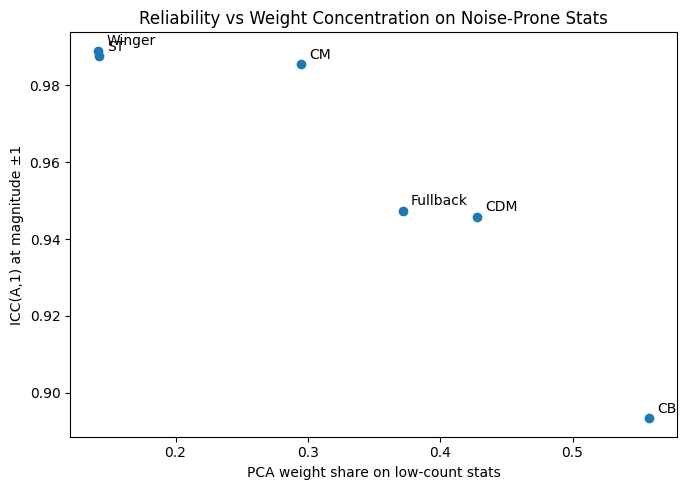

In [78]:
plt.figure(figsize=(7, 5))
plt.scatter(comparison_df['low_count_weight_share'], comparison_df['icc'])
for _, row in comparison_df.iterrows():
    plt.annotate(row['position_group'], (row['low_count_weight_share'], row['icc']),
                 textcoords="offset points", xytext=(6, 4))
plt.xlabel("PCA weight share on low-count stats")
plt.ylabel("ICC(A,1) at magnitude ±1")
plt.title("Reliability vs Weight Concentration on Noise-Prone Stats")
plt.tight_layout()
plt.show()

**This is the strongest single finding in the notebook, and it's a different
kind of finding from the GK result.** GK's collapse was explained away - it was
testing `goals_conceded`, a stat too salient to plausibly be misjudged in
practice, so the alarming numbers didn't reflect a real day-to-day risk.
CB's fragility has no equivalent escape route: `possession_won` and `tackles`
are exactly the inputs already accepted as realistically noisy throughout this
notebook. A position whose rating concentrates roughly half its weight on those
two stats is structurally more exposed to ordinary measurement noise, by
design - not an artefact of an unrealistic test.

Worth being precise about the limits of this specific check, though: six
position groups is a clean visual trend, not a statistically tested one - no
formal correlation test was run here, deliberately, since n=6 isn't enough to
support one without overstating the rigor. The pattern is convincing by eye and
mechanistically explained (the weight vectors are the actual cause, not just a
correlate), which is a stronger basis than a p-value at this sample size would
have been anyway.


## Near-Neighbour Retest

Tests something synthetic perturbation structurally can't: do two genuinely
different real performances that happen to look alike get rated alike? Unlike
perturbation, which only explores the immediate neighbourhood of performances
that already exist, this checks whether any hidden seams in the rating function
sit *between* real, naturally-occurring data points - including ones perturbation
never had reason to walk into.

Position-stratified (CB's weight concentration makes pooling across positions
meaningless here), clustered on a simple per-90 rate z-scored within position
group (not the model's exact internal Bayesian-shrunk features - a deliberate
simplification rather than reverse-engineering the full smoothing formula), and
scored with **one-way ICC**, not the two-way form used everywhere else in this
notebook. Two-way ICC assumes a crossed, balanced design - the same identifiable
"rater" applied to every target - which doesn't hold for k-means clusters of
unequal size with no shared identity across groups. One-way is the form built
for exactly that structure.

In [85]:
# Stats not directly available from raw performance data, excluded from the
# clustering feature space - xt_bonus is a derived internal metric (likely
# distance/progression-based) we can't faithfully reconstruct from raw fields.
# Leaving it as a zero-filled placeholder would be worse than dropping it: a
# constant column has zero variance, and StandardScaler dividing by a std of 0
# produces NaN, corrupting the whole matrix.
EXCLUDED_WEIGHT_STATS = {'xt_bonus'}
RAW_COUNT_STATS = {'goals', 'assists'}  # rare discrete events - raw count, not rate
PERCENTAGE_STATS = {'tackle_success_rate', 'pass_accuracy', 'dribble_success_rate', 'shot_accuracy'}

def build_feature_matrix_weighted(target_ids: list[str], position_weights: dict) -> np.ndarray:
    """Per-90 rate (or raw count / percentage, as appropriate) on every stat the
    position's own weight vector includes that's directly available from raw
    performance data, each scaled by its weight - so similarity reflects what
    the model actually weighs for this position, not a generic borrowed list."""
    rows = []
    for tid in target_ids:
        perf, _, _ = performance_lookup[tid]
        minutes = perf.get('minutes_played', 90) or 90
        row = []
        for weight_key, weight in position_weights.items():
            stat = weight_key.replace('_p90', '')
            if stat in EXCLUDED_WEIGHT_STATS:
                continue
            if stat == 'non_goal_shots':
                value = (perf.get('shots', 0) - perf.get('goals', 0)) / minutes * 90
            elif stat in RAW_COUNT_STATS:
                value = perf.get(stat, 0)
            elif stat in PERCENTAGE_STATS:
                value = perf.get(stat, 0)
            else:
                value = perf.get(stat, 0) / minutes * 90
            row.append(value * weight)
        rows.append(row)
    return np.array(rows)

In [86]:
TARGET_CLUSTER_SIZE = 12

def cluster_position_group(target_ids: list[str], position_weights: dict, seed: int = RANDOM_SEED) -> tuple[np.ndarray, int]:
    features = build_feature_matrix_weighted(target_ids, position_weights)
    features_z = StandardScaler().fit_transform(features)
    n_clusters = max(2, round(len(target_ids) / TARGET_CLUSTER_SIZE))
    labels = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit_predict(features_z)
    return labels, n_clusters

In [87]:
def icc_one_way(values: np.ndarray, group_ids: np.ndarray) -> float:
    """One-way random-effects ICC (Shrout & Fleiss ICC(1) / McGraw & Wong
    ICC(1,1)), generalised for unbalanced groups via the standard k0 correction -
    the appropriate form here since k-means clusters vary in size and there's no
    shared 'rater' identity across clusters for a two-way model to exploit."""
    groups = np.unique(group_ids)
    a = len(groups)
    n = len(values)
    grand_mean = values.mean()

    ssb = 0.0
    ssw = 0.0
    sum_n_sq = 0.0
    for g in groups:
        vals_g = values[group_ids == g]
        n_g = len(vals_g)
        sum_n_sq += n_g ** 2
        ssb += n_g * (vals_g.mean() - grand_mean) ** 2
        ssw += np.sum((vals_g - vals_g.mean()) ** 2)

    msb = ssb / (a - 1)
    msw = ssw / (n - a)
    k0 = (n - sum_n_sq / n) / (a - 1)

    return (msb - msw) / (msb + (k0 - 1) * msw)

In [88]:
near_neighbour_results = []
cluster_assignments = {}  # kept for inspection - which targets landed in which cluster

for group in position_groups_to_test:
    group_target_ids = [tid for tid in valid_targets if target_position_group[tid] == group]
    labels, n_clusters = cluster_position_group(group_target_ids, weights[position_weight_keys[group]])
    ratings = np.array([original_ratings[tid] for tid in group_target_ids])

    icc_value = icc_one_way(ratings, labels)
    near_neighbour_results.append({
        'position_group': group, 'n_targets': len(group_target_ids),
        'n_clusters': n_clusters, 'avg_cluster_size': len(group_target_ids) / n_clusters,
        'icc_one_way': icc_value
    })
    cluster_assignments[group] = (group_target_ids, ratings, labels)

near_neighbour_df = pd.DataFrame(near_neighbour_results)
near_neighbour_df

,position_group,n_targets,n_clusters,avg_cluster_size,icc_one_way
0,CB,428,36,11.888889,0.488665
1,CDM,211,18,11.722222,0.459822
2,CM,449,37,12.135135,0.639636
3,Fullback,405,34,11.911765,0.524218
4,ST,244,20,12.200000,0.537206
5,Winger,452,38,11.894737,0.647784


**Result: ranking now lines up with the synthetic test - Winger (0.648) and CM
(0.640) highest, CB (0.489) and CDM (0.460) lowest - a real change from the
broken feature matrix's complete inversion.** But every position now sits in
"moderate" territory or worse by Koo & Li's bands, well below synthetic
perturbation's "excellent" baseline even for the best-placed positions. Worth
being careful about what that magnitude gap actually means - see the bootstrap
and silhouette checks below before reading too much into it.


In [89]:
def bootstrap_icc_one_way(ratings: np.ndarray, group_ids: np.ndarray, n_resamples: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    unique_groups = np.unique(group_ids)
    n_groups = len(unique_groups)
    group_values = {g: ratings[group_ids == g] for g in unique_groups}

    boot_iccs = np.empty(n_resamples)
    for i in range(n_resamples):
        sampled_groups = rng_local.choice(unique_groups, size=n_groups, replace=True)
        resampled_values, resampled_labels = [], []
        for new_id, g in enumerate(sampled_groups):
            vals = group_values[g]
            resampled_values.extend(vals)
            resampled_labels.extend([new_id] * len(vals))
        boot_iccs[i] = icc_one_way(np.array(resampled_values), np.array(resampled_labels))
    return boot_iccs

ci_results = []
for group in position_groups_to_test:
    _, ratings, labels = cluster_assignments[group]
    boot_iccs = bootstrap_icc_one_way(ratings, labels, n_resamples=N_BOOTSTRAP_RESAMPLES)
    ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
    ci_results.append({'position_group': group, 'ci_low': ci_l, 'ci_high': ci_h})

near_neighbour_df = near_neighbour_df.merge(pd.DataFrame(ci_results), on='position_group')
near_neighbour_df.sort_values('icc_one_way', ascending=False)

,position_group,n_targets,n_clusters,avg_cluster_size,icc_one_way,ci_low,ci_high
5,Winger,452,38,11.894737,0.647784,0.485636,0.758279
2,CM,449,37,12.135135,0.639636,0.452956,0.729876
4,ST,244,20,12.200000,0.537206,0.294952,0.713658
3,Fullback,405,34,11.911765,0.524218,0.326861,0.665365
0,CB,428,36,11.888889,0.488665,0.307696,0.597275
1,CDM,211,18,11.722222,0.459822,0.223862,0.629004


**CIs separate cleanly enough to trust the ranking, with the expected overlap
between adjacent positions.** Winger and CM's intervals overlap heavily with
each other (both clearly "best"), as do CB and CDM's (both clearly "lowest") -
exactly the grouping the point estimates suggested, not noise creating false
separation. ST and Fullback's wide, overlapping CIs in the middle reflect real
sampling uncertainty at these smaller group sizes rather than a precise
ordering between them specifically.


In [90]:
diagnostic_results = []
for group in position_groups_to_test:
    group_target_ids, ratings, labels = cluster_assignments[group]
    minutes = np.array([performance_lookup[tid][0].get('minutes_played', 90) for tid in group_target_ids])

    within_cluster_minutes_std = []
    within_cluster_rating_std = []
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        if mask.sum() > 1:
            within_cluster_minutes_std.append(minutes[mask].std())
            within_cluster_rating_std.append(ratings[mask].std())

    corr, _ = stats.spearmanr(within_cluster_minutes_std, within_cluster_rating_std)
    diagnostic_results.append({'position_group': group, 'minutes_rating_spread_corr': corr})

pd.DataFrame(diagnostic_results)

,position_group,minutes_rating_spread_corr
0,CB,0.141942
1,CDM,0.314286
2,CM,0.203877
3,Fullback,0.415509
4,ST,0.608499
5,Winger,0.246605


**Minutes confound ruled out again under the corrected clustering, consistent
with the first check.** Correlations stay weak-to-moderate across the board
(0.14-0.42), with ST highest at 0.61 - plausibly just reflecting how often
strikers get rotated or rested, not a methodology artefact. Confirms the
earlier finding wasn't a fluke of the broken feature matrix specifically.


In [91]:
from sklearn.metrics import silhouette_score

for group in position_groups_to_test:
    group_target_ids, ratings, labels = cluster_assignments[group]
    position_weights = weights[position_weight_keys[group]]
    features = build_feature_matrix_weighted(group_target_ids, position_weights)
    features_z = StandardScaler().fit_transform(features)
    score = silhouette_score(features_z, labels)
    print(f"{group}: silhouette = {score:.3f}")

CB: silhouette = 0.173
CDM: silhouette = 0.148
CM: silhouette = 0.103
Fullback: silhouette = 0.124
ST: silhouette = 0.123
Winger: silhouette = 0.122


**This check cuts in a reassuring direction rather than an alarming one, and
the detail matters more than the raw numbers.** All six scores sit in the same
weak-to-moderate band (0.10-0.17) - real performances fall along a continuum,
not sharp natural clusters, so the absolute ICC values deserve real epistemic
humility rather than being read as precise reliability figures the way the
synthetic test's 0.9745 was. But critically, cluster quality runs in the
*opposite* direction from what would explain the ranking as an artefact: CB has
the *best* silhouette score (0.173) and one of the *worst* ICC values (0.489);
CM and Winger have the *worst* silhouette scores (0.103, 0.122) and the *best*
ICC values. If weak clustering were manufacturing CB's apparent fragility,
you'd expect bad clustering to drag ICC down, not up - so whatever's driving
the position differences, it isn't differential cluster quality. Combined with
the synthetic test's independent agreement on the same ranking, this is solid
corroborating evidence for the CB/CDM finding, even though the near-neighbour
ICC's absolute value shouldn't be treated as a standalone precise figure.


## Caveats

- **half_length is out of scope, not just untested.** Zero variance across all
  155 matches makes the real underlying question (does real human input
  genuinely scale linearly with available real-world time) empirically
  untestable right now. Separately, even a synthetic counterfactual built to
  test pipeline-level implementation correctness would be circular:
  `half_length` is referenced exactly once in each rating method, purely to
  compute `time_scalar`, and never touched again - so any counterfactual built
  to invert that scalar guarantees identical downstream inputs and therefore
  identical final ratings, regardless of whether a bug exists anywhere else in
  the code. There's no test this notebook's methodology could run that would
  tell you anything new about it.
- **GK's sample size (~155) is much smaller than outfield's (~2191) throughout.**
  Point estimates track outfield closely, but every GK confidence interval is
  correspondingly wider - visible directly in the combined plot's diverging
  bands at higher noise magnitudes.
- **The clean-sheet architectural discontinuity is documented, not fixed.**
  This notebook diagnoses the mechanism and confirms it doesn't currently bite
  under realistic noise - it doesn't change the underlying code. Two keepers
  with near-identical true performances landing on opposite sides of the
  goals_conceded 0/1/penalty/shootout boundary could still receive meaningfully
  different ratings for reasons unrelated to a genuine quality difference, any
  time that boundary actually gets crossed by a real result rather than
  synthetic noise.
- **The same applies to defender/CM clean-sheet bonuses, untested here for a
  different reason.** `_apply_defender_clean_sheet_bonus` and
  `_apply_cm_clean_sheet_bonus` share GK's discrete-gate pattern, but they're
  gated on team-level `opponent_goals`/`opponent_xg`, which this notebook's
  noise model never perturbs (only individual player stats are varied). Whether
  that boundary is fragile in the same way GK's is remains genuinely untested,
  not ruled out.
- **The position-weight-concentration finding is a clean descriptive pattern
  across six groups, not a statistically tested one.** n=6 doesn't support a
  formal correlation test without overstating the rigor - the mechanistic
  explanation (the actual weight vectors) is doing the load-bearing work here,
  not a p-value.
- **Near-neighbour retest's absolute ICC values shouldn't be read as precise
  reliability figures the way the synthetic test's were.** Silhouette scores
  (0.10-0.17 across all six groups) indicate real performances sit on a
  continuum rather than falling into sharp natural clusters - some of the
  "within-cluster" variance this test measures is cluster-boundary fuzziness,
  not necessarily reliability noise. The *ranking* across positions is
  well-corroborated (matches the synthetic test, and cluster quality runs in
  the wrong direction to explain it as an artefact); the *magnitude* of each
  position's ICC is not equally trustworthy.
- **Synthetic perturbation and near-neighbour retest measure reliability at
  different scales of "similar," and their absolute values aren't directly
  comparable.** A synthetic variant differs from its original by a tiny,
  controlled nudge on a few stats. A k-means cluster groups performances close
  in aggregate, multi-dimensional, weighted distance - a coarser, more
  permissive notion of "similar" that naturally allows more real variation
  between members. Near-neighbour's lower absolute ICCs reflect that broader
  neighbourhood, not a contradiction of the synthetic result.
- **Realistic-noise judgement calls (which stats to perturb, which to treat as
  un-misjudgeable) were made by reasoning about salience, not validated
  empirically against how users actually behave when correcting OCR output.**
  Defensible, consistent with the same standard applied to goals/assists, but a
  judgement call rather than a measured fact.


## Conclusions

**What this notebook set out to test:** whether the rating is stable when fed
genuinely-irrelevant input noise - the kind of off-by-one ambiguity that could
plausibly survive a user's validation step - and, separately, whether genuinely
different real performances that happen to look alike actually get rated alike.
A different question from 3.7's construct validity (does the rating track the
right thing); this is about whether the measurement itself is trustworthy once
you grant that it's broadly measuring the right construct.

### What holds up

**Pooled outfield reliability is excellent** - ICC(A,1) = 0.9745 (bootstrap CI
[0.9723, 0.9765]) under realistic small noise, with graceful, near-linear
degradation across the magnitude sweep rather than any cliff. But this pooled
number turned out to mask a real, position-specific gap - see below.

**GK reliability is equally excellent, once one structurally fragile input is
set aside.** The initial four-stat test collapsed alarmingly (0.5906 at
magnitude +/-1), but the diagnosis traced this entirely to `goals_conceded` - a
stat that, like goals and assists for outfield players, is too salient and
discrete to plausibly be misjudged in the first place. Excluding it produces a
curve (0.9800 -> 0.8429) that closely tracks outfield's at every magnitude
tested.

### What's real but smaller than the initial result suggested

**The GK rating formula has a genuine architectural discontinuity around
goals_conceded, independent of whether realistic noise ever triggers it.** A
hard equality gate (`goals_conceded == 0`) switches an entire bonus-calculation
branch on or off, compounded by a second gate at exactly one goal conceded, and
the same gate extends across penalty and shootout goals too. Worth documenting
as a property of the algorithm's design - this notebook shows it's not a
problem under the kind of input noise that's actually plausible, not that the
discontinuity doesn't exist.

### What's real and does NOT have the same escape route

**CB (and, to a lesser extent, CDM) ratings are meaningfully less reliable than
CM and Winger, and this is now corroborated by two independent methods, not
just one.** Synthetic perturbation found CB falling fastest and furthest under
input noise (0.893 -> 0.524 across the magnitude sweep, while CM/Winger/ST
stayed above 0.90 even at the highest magnitude tested), traced directly to
CB's PCA weight vector concentrating roughly 51% of its weight on
`possession_won` + `tackles` + `possession_lost` - three of the lowest-
natural-count stats in the dataset - against CM's far more diffuse weighting
across seventeen inputs. Near-neighbour retest, built and run independently
(real performances clustered by position-appropriate weighted similarity,
scored with one-way ICC), found the same ranking: CM (0.640) and Winger (0.648)
most reliable, CB (0.489) and CDM (0.460) least. A silhouette check ruled out
the obvious alternative explanation - cluster quality runs in the *opposite*
direction from what would be needed to explain CB's low score as a clustering
artefact. Two independently-designed tests agreeing on the same ranking, with
the most likely confound checked and ruled out, is about as solid a basis as
this kind of internal validation can produce. And `possession_won`/`tackles`,
unlike `goals_conceded`, are inputs already accepted elsewhere in this notebook
as realistically misjudgeable - so unlike the GK finding, there's no "this
would never actually happen" escape route here. The lever is visible directly
in the weight vector: CB's weighting could be diversified the way CM's already
is, at some cost to how distinctively defensive the rating currently feels.

### What's still open

**half_length remains genuinely untested**, for reasons that go beyond "we don't
have the data" - the mechanism itself (a single-use scalar with no downstream
reference) makes any synthetic test circular by construction.

**Defender and CM clean-sheet bonuses share GK's discrete-gate pattern but
weren't tested**, since they're gated on team-level opponent_goals/opponent_xg
rather than individual stats this notebook's noise model touches.

**Near-neighbour retest's absolute ICC values carry real uncertainty from weak
cluster separation** (silhouette 0.10-0.17 across all six groups) - the
*ranking* is well-corroborated, the specific magnitude of any one position's
score is not.

### What this means for the algorithm overall

Combined with 3.7: the rating tracks genuine, position-appropriate performance
signal (construct validity) and is largely stable against realistic measurement
noise (reliability) - but that reliability isn't uniform across positions, and
the gap traces to a specific, identifiable design choice, corroborated by two
independent tests rather than resting on one. Three concrete, actionable
findings for the whitepaper came out of this notebook: GK's clean-sheet
discontinuity (currently undocumented, low real-world risk given input
salience), CB/CDM's weight-concentration-driven reliability gap (currently
undocumented, real risk given that its dominant inputs are exactly the kind
already accepted as noisy, and now corroborated two separate ways), and the
defender/CM clean-sheet gate's untested status (flagged, not yet investigated).
All three are decisions for whoever maintains the algorithm to make
deliberately, rather than properties that should keep sitting undocumented.

This closes out 3.4. 3.5 (sensitivity to the model's own free parameters - PCA
weights, smoothing constants, supremacy bounds) remains the one piece of the
original validation methodology not yet started - and the CB finding here is
itself a natural entry point into it, since it's really asking what happens
when the model's weight vector, not the input data, is the thing varying.
